#Fashin MNIST
Fashion Mnist는 옷, 바지 등 10가지 종류의 의류로 구성된 데이터입니다. 이 데이터는 (28, 28) 크기로 구성되어 있으며 Training Set 6만장, Test Set 1만장으로 총합 7만장으로 이루어져 있습니다. Keras에서 dataset을 import 할 수 있고, 처음 import 시 다운로드 하는 과정이 추가됩니다.

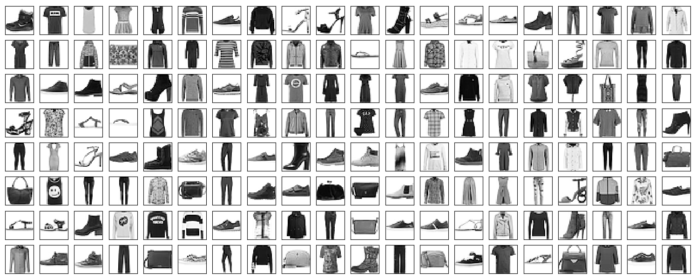


In [2]:
from tensorflow.keras import datasets, layers, models, utils
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt

In [3]:
(x_train2d, y_train),(x_test2d, y_test) = datasets.fashion_mnist.load_data()

In [4]:
print(x_train2d.shape, y_train.shape)
print(x_test2d.shape, y_test.shape)

(60000, 28, 28) (60000,)
(10000, 28, 28) (10000,)


In [5]:
items = {0:'T-shirt/top', 1:'Trouser', 2:'Pullover', 3:'Dress',
         4:'Coat', 5:'Sandal', 6:'Shirt', 7:'Sneaker',
         8:'Bag', 9:'Ankel boot'}

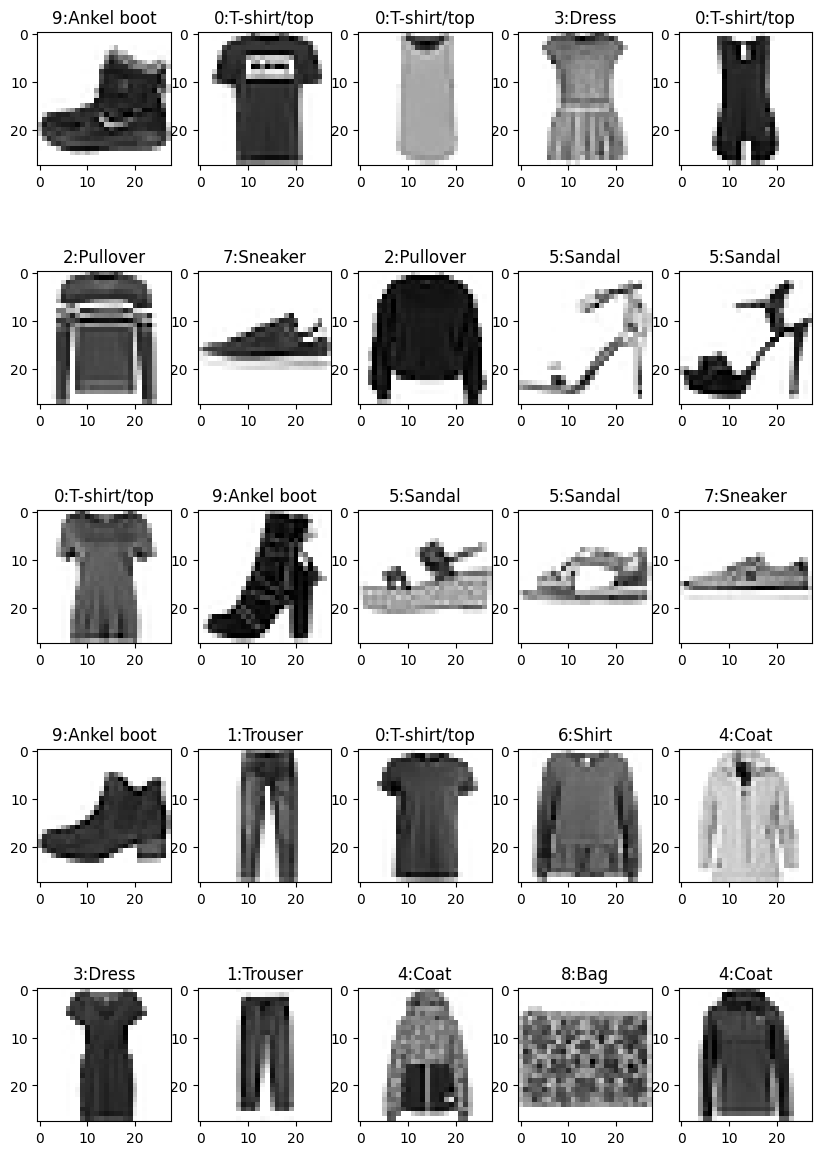

In [7]:
fig, axs = plt.subplots(5, 5, figsize=(10,15))
for i in range(5):
  for j in range(5):
    axs[i, j].set_title('{}:{}'.format(y_train[i*5+j], items[y_train[i*5+j]]))
    axs[i, j].imshow(x_train2d[i*5+j], cmap='gray_r')
plt.show()

In [8]:
x_train = x_train2d.reshape(-1, 28, 28, 1)
x_test = x_test2d.reshape(-1, 28, 28, 1)

In [9]:
x_train = x_train / 255
x_test = x_test / 255

#모델구성

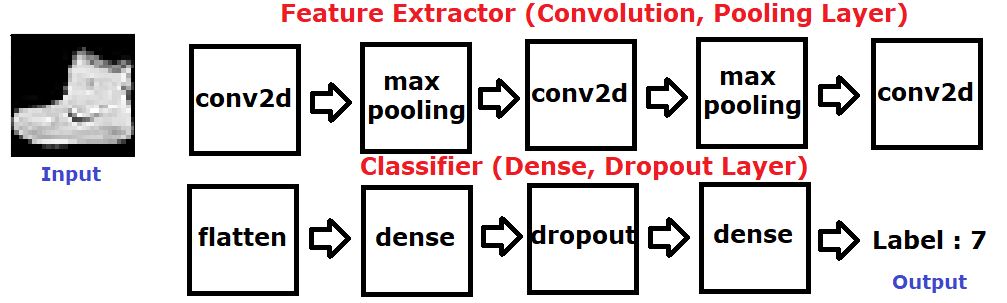

## Feature Extractor

In [10]:
model = models.Sequential()
model.add(layers.Conv2D(32, (3,3), padding='same', activation='relu', input_shape=(28,28,1)))
model.add(layers.MaxPooling2D((2,2), strides=2))
model.add(layers.Conv2D(64, (3,3), padding='same', activation='relu'))
model.add(layers.MaxPooling2D((2,2), strides=2))
model.add(layers.Conv2D(128, (3,3), padding='same', activation='relu'))
model.summary()

/opt/homebrew/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 128)      │        73,856 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 92,672 (362.00 KB)

 Trainable params: 92,672 (362.00 KB)

 Non-trainable params: 0 (0.00 B)

### Classifier

In [11]:
model.add(layers.Flatten())
model.add(layers.Dense(128, activation='relu'))
model.add(layers.Dense(10, activation='softmax'))
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       802,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 896,906 (3.42 MB)

 Trainable params: 896,906 (3.42 MB)

 Non-trainable params: 0 (0.00 B)

In [14]:
model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['acc'])
history = model.fit(x_train, y_train, epochs=10, validation_split=0.2)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - acc: 0.8457 - loss: 0.4218 - val_acc: 0.8881 - val_loss: 0.3076
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - acc: 0.9009 - loss: 0.2685 - val_acc: 0.9047 - val_loss: 0.2623
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - acc: 0.9188 - loss: 0.2226 - val_acc: 0.9117 - val_loss: 0.2393
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - acc: 0.9299 - loss: 0.1873 - val_acc: 0.9120 - val_loss: 0.2383
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - acc: 0.9402 - loss: 0.1587 - val_acc: 0.9215 - val_loss: 0.2187
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - acc: 0.9506 - loss: 0.1305 - val_acc: 0.9204 - val_loss: 0.2266
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - acc: 0.9593 - loss: 0.1086 - val_acc: 0.9135 - val_loss: 0.2573
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - acc: 0.9663 - loss: 0.0877 - val_acc: 0.9192 - val_loss: 0.2632
Epoch 9/10
1500/1500 ━━━━━━━━━━━

In [15]:
def plot_history(history):
    plt.figure(figsize=(15,5))
    plt.subplot(1,2,1)
    plt.plot(history['acc'])
    plt.plot(history['val_acc'])
    plt.legend(['train', 'val'])
    plt.title('accuracy')
    plt.subplot(1,2,2)
    plt.plot(history['loss'])
    plt.plot(history['val_loss'])
    plt.legend(['train', 'val'])
    plt.title('loss')
    plt.show()  

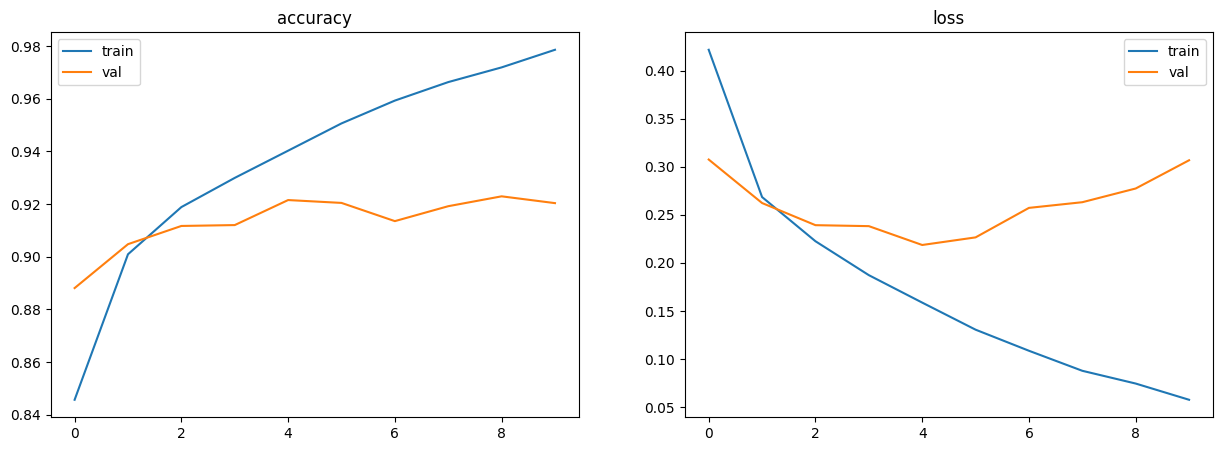

In [16]:
plot_history(history.history)

#Drop out
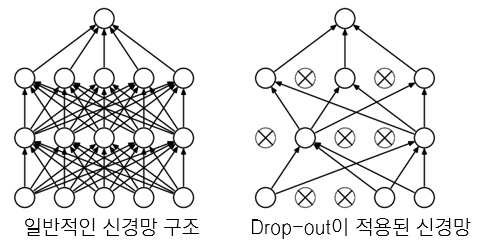

## BatchNormalization
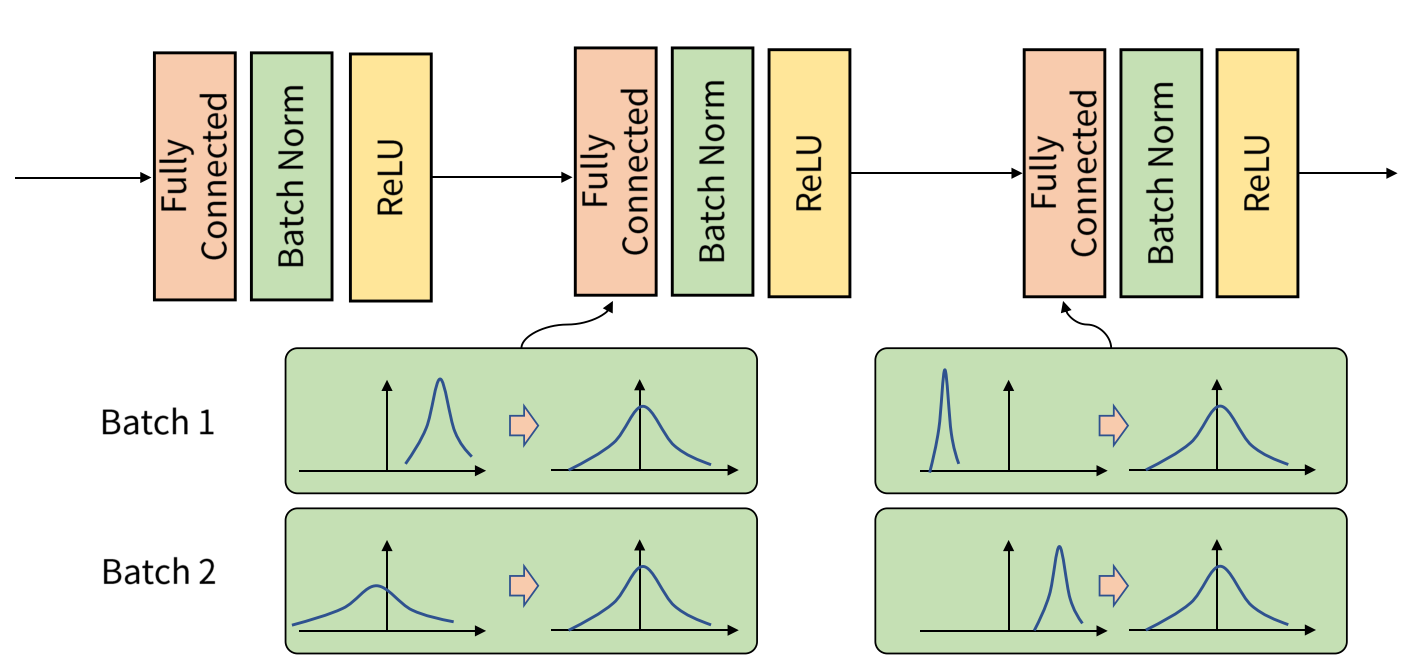

In [17]:
model2 = models.Sequential()
model2.add(layers.Conv2D(32, (3,3), padding='same', activation='relu', input_shape=(28,28,1)))
model2.add(layers.BatchNormalization())
model2.add(layers.MaxPooling2D((2,2), strides=2))
model2.add(layers.Conv2D(64, (3,3), padding='same', activation='relu'))
model2.add(layers.BatchNormalization())
model2.add(layers.MaxPooling2D((2,2), strides=2))
model2.add(layers.Conv2D(128, (3,3), padding='same', activation='relu'))
model2.add(layers.Flatten())
model2.add(layers.Dense(128, activation='relu'))
model2.add(layers.Dropout(0.3))
model2.add(layers.Dense(10, activation='softmax'))
model2.summary()

/opt/homebrew/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       802,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 897,290 (3.42 MB)

 Trainable params: 897,098 (3.42 MB)

 Non-trainable params: 192 (768.00 B)

In [22]:
model2.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['acc'])

In [23]:
history = model2.fit(x_train, y_train, epochs=10, validation_split=0.2)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - acc: 0.9602 - loss: 0.1098 - val_acc: 0.9080 - val_loss: 0.3754
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - acc: 0.9654 - loss: 0.0955 - val_acc: 0.9198 - val_loss: 0.2871
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - acc: 0.9672 - loss: 0.0891 - val_acc: 0.9197 - val_loss: 0.3139
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - acc: 0.9712 - loss: 0.0795 - val_acc: 0.9160 - val_loss: 0.3205
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 16s 10ms/step - acc: 0.9731 - loss: 0.0763 - val_acc: 0.9164 - val_loss: 0.4283
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 16s 11ms/step - acc: 0.9739 - loss: 0.0719 - val_acc: 0.9169 - val_loss: 0.4517
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 14s 10ms/step - acc: 0.9766 - loss: 0.0651 - val_acc: 0.9178 - val_loss: 0.3620
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - acc: 0.9770 - loss: 0.0635 - val_acc: 0.9229 - val_loss: 0.4416
Epoch 9/10
1500/1500 ━━━━━━

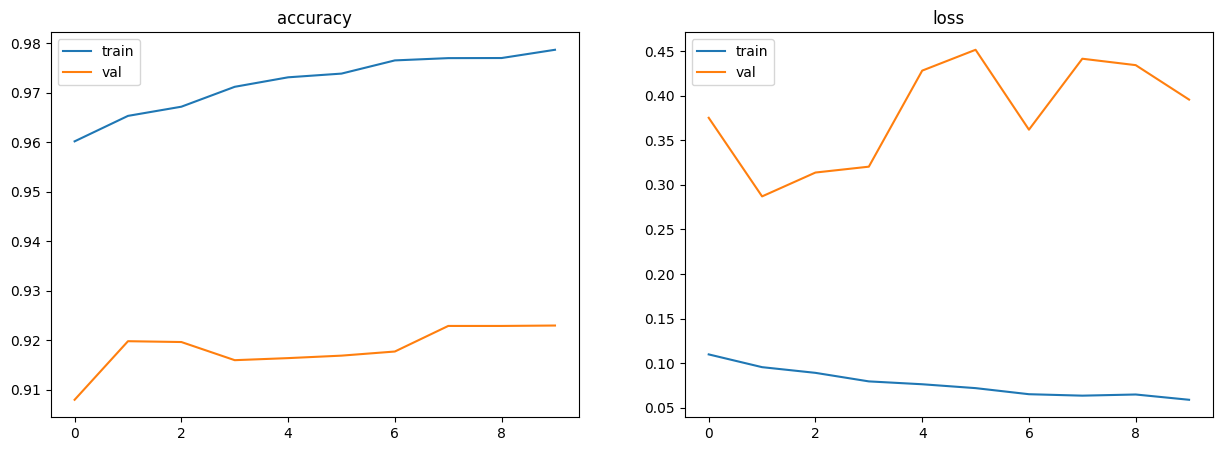

In [24]:
plot_history(history.history)

In [25]:
model2.evaluate(x_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - acc: 0.9200 - loss: 0.4517


[0.4517216384410858, 0.9200000166893005]

## Callback

In [26]:
model3 = models.Sequential()
model3.add(layers.Conv2D(32, (3,3), padding='same', activation='relu', input_shape=(28,28,1)))
model3.add(layers.Dropout(0.3))
model3.add(layers.MaxPooling2D((2,2), strides=2))
model3.add(layers.Conv2D(64, (3,3), padding='same', activation='relu'))
model3.add(layers.MaxPooling2D((2,2), strides=2))
model3.add(layers.Conv2D(128, (3,3), padding='same', activation='relu'))
model3.add(layers.Flatten())
model3.add(layers.Dense(128, activation='relu'))
model3.add(layers.Dropout(0.3))
model3.add(layers.Dense(10, activation='softmax'))
model3.summary()

/opt/homebrew/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       802,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 896,906 (3.42 MB)

 Trainable params: 896,906 (3.42 MB)

 Non-trainable params: 0 (0.00 B)

In [27]:
model3.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['acc'])

In [28]:
checkpoint_cb = keras.callbacks.ModelCheckpoint('best_model.h5')
history = model3.fit(x_train, y_train, epochs=10,
                     validation_split=0.2,
                     callbacks=[checkpoint_cb])

Epoch 1/10
1494/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - acc: 0.7553 - loss: 0.6732

1500/1500 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - acc: 0.8283 - loss: 0.4793 - val_acc: 0.8815 - val_loss: 0.3106
Epoch 2/10
1498/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - acc: 0.8820 - loss: 0.3231

1500/1500 ━━━━━━━━━━━━━━━━━━━━ 14s 10ms/step - acc: 0.8876 - loss: 0.3074 - val_acc: 0.9059 - val_loss: 0.2588
Epoch 3/10
1495/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - acc: 0.9034 - loss: 0.2627

1500/1500 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - acc: 0.9043 - loss: 0.2606 - val_acc: 0.9084 - val_loss: 0.2582
Epoch 4/10
1496/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - acc: 0.9155 - loss: 0.2290

1500/1500 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - acc: 0.9156 - loss: 0.2286 - val_acc: 0.9118 - val_loss: 0.2470
Epoch 5/10
1499/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - acc: 0.9253 - loss: 0.1987

...

1500/1500 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - acc: 0.9331 - loss: 0.1808 - val_acc: 0.9202 - val_loss: 0.2234
Epoch 7/10
1496/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - acc: 0.9386 - loss: 0.1659

1500/1500 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - acc: 0.9379 - loss: 0.1649 - val_acc: 0.9261 - val_loss: 0.2235
Epoch 8/10
1494/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - acc: 0.9458 - loss: 0.1459

1500/1500 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - acc: 0.9434 - loss: 0.1516 - val_acc: 0.9230 - val_loss: 0.2148
Epoch 9/10
1498/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - acc: 0.9467 - loss: 0.1365

1500/1500 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - acc: 0.9473 - loss: 0.1387 - val_acc: 0.9238 - val_loss: 0.2272
Epoch 10/10
1499/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - acc: 0.9545 - loss: 0.1188

1500/1500 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - acc: 0.9534 - loss: 0.1242 - val_acc: 0.9237 - val_loss: 0.2332


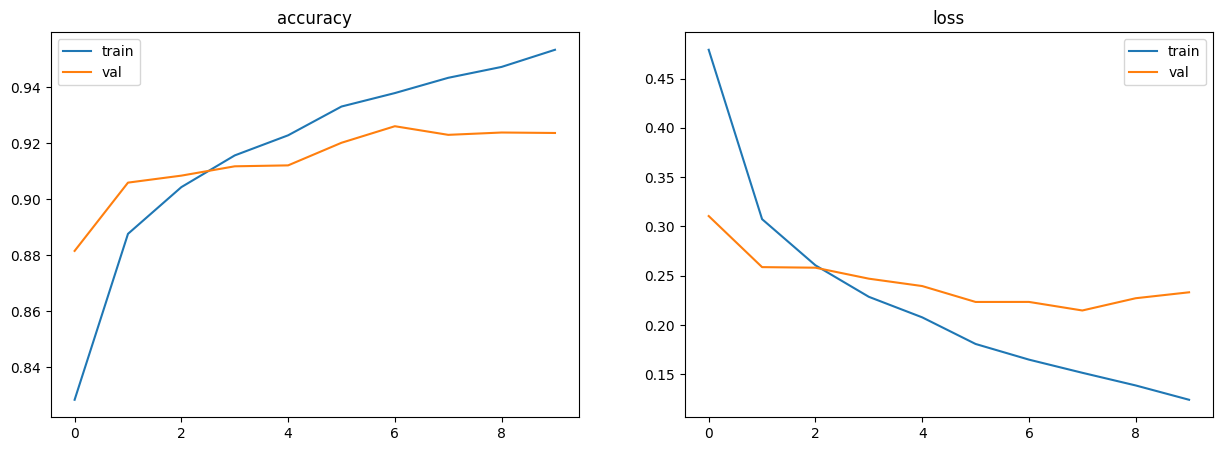

In [29]:
plot_history(history.history)

In [30]:
model3.evaluate(x_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - acc: 0.9198 - loss: 0.2511


[0.2511158287525177, 0.9197999835014343]

In [ ]:
pred=model4.predict(x_test[0:25])
print(np.round(pred, decimals=3))

In [31]:
model4 = models.Sequential()
model4.add(layers.Conv2D(32, (3,3), padding='same', activation='relu', input_shape=(28,28,1)))
model4.add(layers.Dropout(0.3))
model4.add(layers.MaxPooling2D((2,2), strides=2))
model4.add(layers.Conv2D(64, (3,3), padding='same', activation='relu'))
model4.add(layers.MaxPooling2D((2,2), strides=2))
model4.add(layers.Conv2D(128, (3,3), padding='same', activation='relu'))
model4.add(layers.Flatten())
model4.add(layers.Dense(128, activation='relu'))
model4.add(layers.Dropout(0.3))
model4.add(layers.Dense(10, activation='softmax'))
model4.summary()

/opt/homebrew/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │       802,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 896,906 (3.42 MB)

 Trainable params: 896,906 (3.42 MB)

 Non-trainable params: 0 (0.00 B)

In [32]:
model4.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['acc'])

In [33]:
checkpoint_cb = keras.callbacks.ModelCheckpoint('best_model.h5')
earlystopping_cb = keras.callbacks.EarlyStopping(patience=3,
                              restore_best_weights=True)
history = model4.fit(x_train, y_train, epochs=10,
                     validation_split=0.2,
                     callbacks=[checkpoint_cb, earlystopping_cb])

Epoch 1/10
1497/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - acc: 0.7623 - loss: 0.6514

1500/1500 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - acc: 0.8308 - loss: 0.4693 - val_acc: 0.8892 - val_loss: 0.3172
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - acc: 0.8899 - loss: 0.3089

1500/1500 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - acc: 0.8911 - loss: 0.3022 - val_acc: 0.9011 - val_loss: 0.2703
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - acc: 0.9024 - loss: 0.2642

1500/1500 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - acc: 0.9049 - loss: 0.2580 - val_acc: 0.9130 - val_loss: 0.2456
Epoch 4/10
1499/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - acc: 0.9188 - loss: 0.2222

1500/1500 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - acc: 0.9172 - loss: 0.2258 - val_acc: 0.9103 - val_loss: 0.2467
Epoch 5/10
1495/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - acc: 0.9260 - loss: 0.1974

...

1500/1500 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - acc: 0.9315 - loss: 0.1816 - val_acc: 0.9122 - val_loss: 0.2267
Epoch 7/10
1497/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - acc: 0.9435 - loss: 0.1523

1500/1500 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - acc: 0.9399 - loss: 0.1621 - val_acc: 0.9202 - val_loss: 0.2233
Epoch 8/10
1499/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - acc: 0.9480 - loss: 0.1388

1500/1500 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - acc: 0.9441 - loss: 0.1490 - val_acc: 0.9099 - val_loss: 0.2594
Epoch 9/10
1496/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - acc: 0.9499 - loss: 0.1290

1500/1500 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - acc: 0.9488 - loss: 0.1333 - val_acc: 0.9170 - val_loss: 0.2355
Epoch 10/10
1495/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - acc: 0.9563 - loss: 0.1132

1500/1500 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - acc: 0.9545 - loss: 0.1196 - val_acc: 0.9237 - val_loss: 0.2358


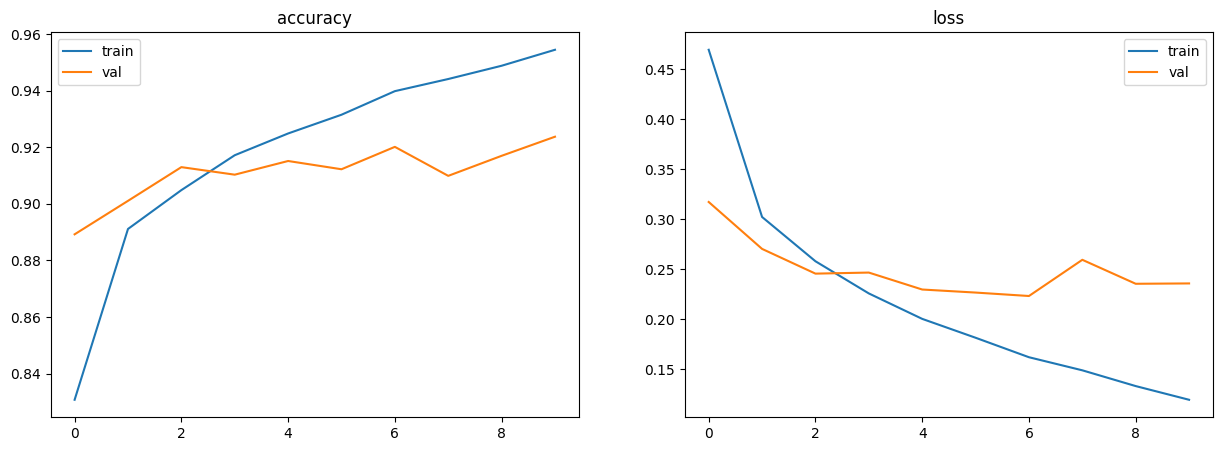

In [34]:
plot_history(history.history)

In [35]:
pred=model4.predict(x_test[0:25])
print(np.round(pred, decimals=3))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
[[0.    0.    0.    0.    0.    0.    0.    0.    0.    1.   ]
 [0.    0.    1.    0.    0.    0.    0.    0.    0.    0.   ]
 [0.    1.    0.    0.    0.    0.    0.    0.    0.    0.   ]
 [0.    1.    0.    0.    0.    0.    0.    0.    0.    0.   ]
 [0.005 0.    0.    0.    0.001 0.    0.994 0.    0.    0.   ]
 [0.    1.    0.    0.    0.    0.    0.    0.    0.    0.   ]
 [0.    0.    0.004 0.    0.996 0.    0.    0.    0.    0.   ]
 [0.    0.    0.    0.    0.004 0.    0.996 0.    0.    0.   ]
 [0.    0.    0.    0.    0.    1.    0.    0.    0.    0.   ]
 [0.    0.    0.    0.    0.    0.    0.    1.    0.    0.   ]
 [0.    0.    0.004 0.    0.99  0.    0.007 0.    0.    0.   ]
 [0.    0.    0.    0.    0.    1.    0.    0.    0.    0.   ]
 [0.    0.    0.    0.    0.    0.014 0.    0.985 0.    0.   ]
 [0.    0.    0.    1.    0.    0.    0.    0.    0.    0.   ]
 [0.    0.    0.03  0.    0.967 0.    0.003 0.    0.    0.   ]
 [0.    1.    0. 

In [36]:
np.argmax(pred,axis=1)

array([9, 2, 1, 1, 6, 1, 4, 6, 5, 7, 4, 5, 7, 3, 4, 1, 2, 4, 8, 0, 2, 5,
       7, 5, 1])

In [37]:
print(y_test[0:25])

[9 2 1 1 6 1 4 6 5 7 4 5 7 3 4 1 2 4 8 0 2 5 7 9 1]


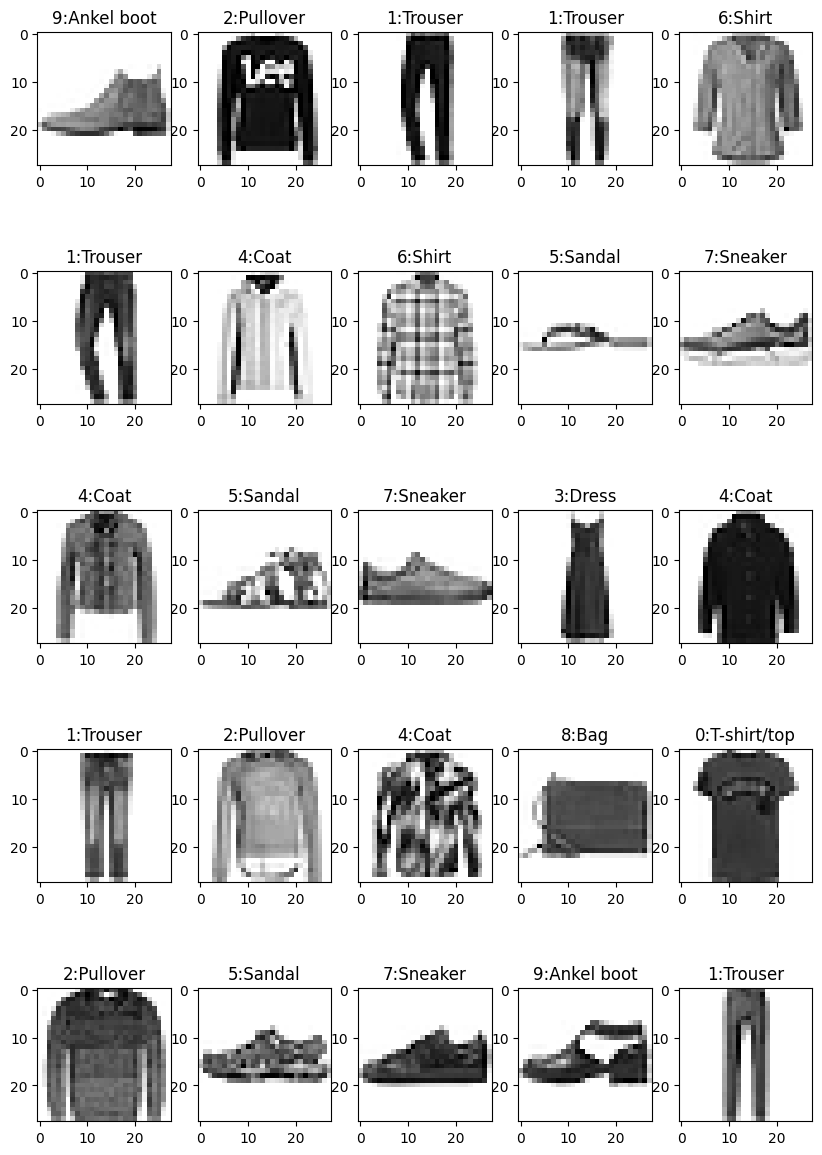

In [39]:
fig, axs = plt.subplots(5, 5, figsize=(10,15))
for i in range(5):
  for j in range(5):
    axs[i, j].set_title('{}:{}'.format(y_test[i*5+j], items[y_test[i*5+j]]))
    axs[i, j].imshow(x_test2d[i*5+j], cmap='gray_r')
plt.show()

## CNN의 시각화

### 학습된 Conv층 가져오기

### 필터를 거친 이미지 확인하기